In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC_0D
from model.coefficients import *
from model.kinetic_eq import *
from modules.signals import generate_step_load
from config.initialize import *
from config.settings import *

In [3]:
# Setup load profile
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.5    # time (within a period) the ramp BEGINS  [s]
t_switch   = 1   # effective ramp duration                 [s]
step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

## Dual scale solution - 0D model
###  Setup the operation condition

An initial solution is obtained for the value initilization in the  AST simulation. 

In [4]:
model = PEMFC_0D(parameters, operating_inputs)
x_init = [0.00033195, 0.0012692, 0.0011941, 0.0074, 0.00075, 1.255e5, 0, model.Hmem] + model.prd0.tolist() + model.theta_ccl.tolist()

In [5]:
sol = solve_ivp(model.dxdt, t_span=(0, 60), y0=x_init, method="BDF")

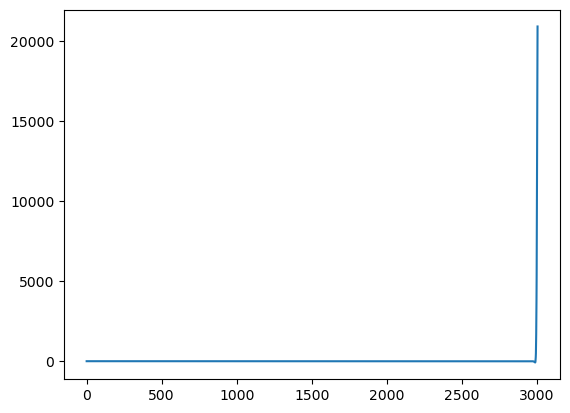

In [6]:
plt.plot(sol.y[0,:])